# VECTRA-X · 03 — Explainability, Uncertainty, Conformal & Triage

Loads the cohort artifacts from `run_pipeline.py` and demonstrates calibration, uncertainty, conformal prediction sets, explainability and the triage engine.

In [1]:
# --- robust project bootstrap: works whether launched from notebooks/ or root ---
import sys, os
from pathlib import Path
p = Path.cwd()
while not (p / 'src').exists() and p != p.parent:
    p = p.parent
sys.path.insert(0, str(p)); os.chdir(p)
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
pd.set_option('display.max_columns', 40); pd.set_option('display.width', 160)
from IPython.display import Image, display
from src import report_utils as ru
cfg = ru.load_config(); RS = cfg['project']['random_state']
FIG = ru.resolve(cfg['paths']['figures']); TAB = ru.resolve(cfg['paths']['tables'])
print('Project root:', p)


Project root: C:\Users\rapha\Documents\VSCode\Kaggle\FIT\vectra_x_project


In [2]:
import joblib
from src import conformal as cf, triage_engine as te
art = joblib.load(ru.resolve(cfg['paths']['dashboard_data']) / 'artifacts.joblib')
active = art['active']
cohort_proba, cohort_cal = art['cohort_proba'], art['cohort_cal']
print('labels:', active, '| cohort:', cohort_proba.shape)

labels: ['malaria', 'other_diseases', 'dengue', 'typhoid', 'yellow_fever'] | cohort: (300, 5)


## Calibration (per-label Brier / ECE) and reliability curve

,label,base_rate,brier,ece,mean_pred,variant
0,malaria,0.8701,0.1071,0.0579,0.8461,uncalibrated
1,other_diseases,0.3247,0.0380,0.1337,0.3387,uncalibrated
2,dengue,0.1818,0.1299,0.0922,0.2600,uncalibrated
3,typhoid,0.0909,0.1008,0.1121,0.1588,uncalibrated
4,yellow_fever,0.0390,0.0338,0.0445,0.0796,uncalibrated
5,malaria,0.8701,0.1109,0.0465,0.9167,calibrated
6,other_diseases,0.3247,0.0146,0.0237,0.3224,calibrated
7,dengue,0.1818,0.1219,0.0715,0.1714,calibrated
8,typhoid,0.0909,0.0793,0.0513,0.0835,calibrated
9,yellow_fever,0.0390,0.0363,0.0020,0.0370,calibrated


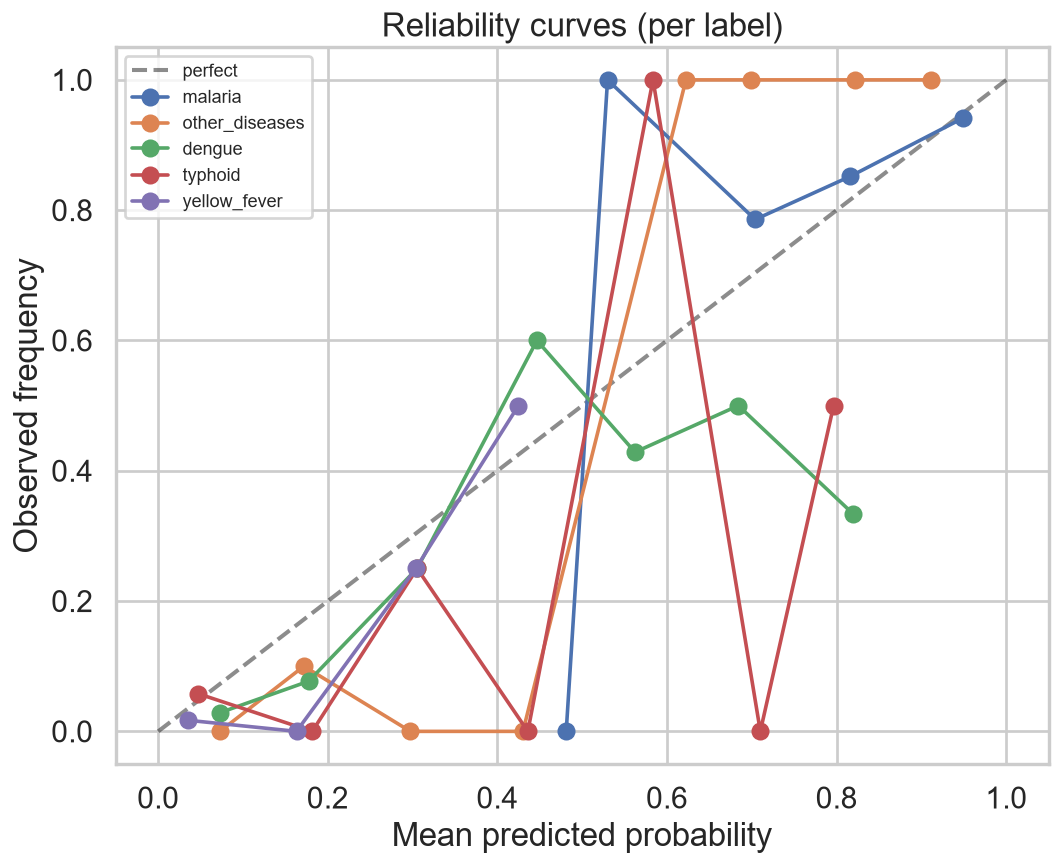

In [3]:
cmet = pd.read_csv(TAB / 'calibration_metrics.csv'); display(cmet)
if (FIG / 'calibration_curves.png').exists(): display(Image(str(FIG / 'calibration_curves.png')))

## Uncertainty + conformal prediction sets

In [4]:
sets = cf.predict_sets(cohort_proba, art['cohort_conf'], active)
sizes = np.array([len(s) for s in sets])
unc = te.uncertainty_scores(cohort_cal, active, sizes)
print('uncertainty levels:', unc['uncertainty_level'].value_counts().to_dict())
print('avg conformal set size:', round(sizes.mean(), 2))
pd.read_csv(TAB / 'conformal_prediction_examples.csv').head(12)

uncertainty levels: {'moderate': 138, 'low': 118, 'high': 44}
avg conformal set size: 2.91


,uuid,prediction_set,set_size,true_labels,interpretation,max_prob
0,eb694f52-51ff-488d-9beb-2923a572a4cf,"{malaria, dengue, typhoid, yellow_fever}",4,{malaria},ambiguous — request confirmatory testing,0.894
1,3f96e3e8-d1ed-4ff4-b945-8088af180529,"{malaria, dengue, typhoid, yellow_fever}",4,"{malaria, dengue}",ambiguous — request confirmatory testing,0.823
2,f41c7b5c-d560-4352-82b2-cebfcdf2a68a,"{malaria, dengue, typhoid, yellow_fever}",4,"{malaria, dengue}",ambiguous — request confirmatory testing,0.874
3,83257713-90ef-47db-acb6-f977a4b8ee1a,"{malaria, dengue, typhoid, yellow_fever}",4,"{dengue, yellow_fever}",ambiguous — request confirmatory testing,0.874
4,76d34d9f-4f0b-4bb3-b610-8f41510b0aab,"{malaria, dengue, typhoid, yellow_fever}",4,{dengue},ambiguous — request confirmatory testing,0.707
5,f5c31a1e-6059-44fb-8d10-feb7891a93ea,"{malaria, other_diseases, typhoid, yellow_fever}",4,"{malaria, other_diseases}",ambiguous — request confirmatory testing,0.881
6,2e80ed76-27fd-467c-b9d8-fa3be6dd72a3,"{malaria, typhoid}",2,{malaria},ambiguous — request confirmatory testing,0.944
7,708eccbd-9604-491a-b41c-6026aba3c908,"{malaria, other_diseases, dengue, typhoid, yel...",5,"{malaria, other_diseases}",ambiguous — request confirmatory testing,0.806
8,8648cafa-454c-45d1-80e2-afdb5f25fd2b,"{malaria, other_diseases, dengue, typhoid, yel...",5,"{other_diseases, dengue}",ambiguous — request confirmatory testing,0.798
9,cc1f97c7-8bef-484a-9fc5-7ea18c162db5,"{malaria, dengue, typhoid, yellow_fever}",4,{malaria},ambiguous — request confirmatory testing,0.934


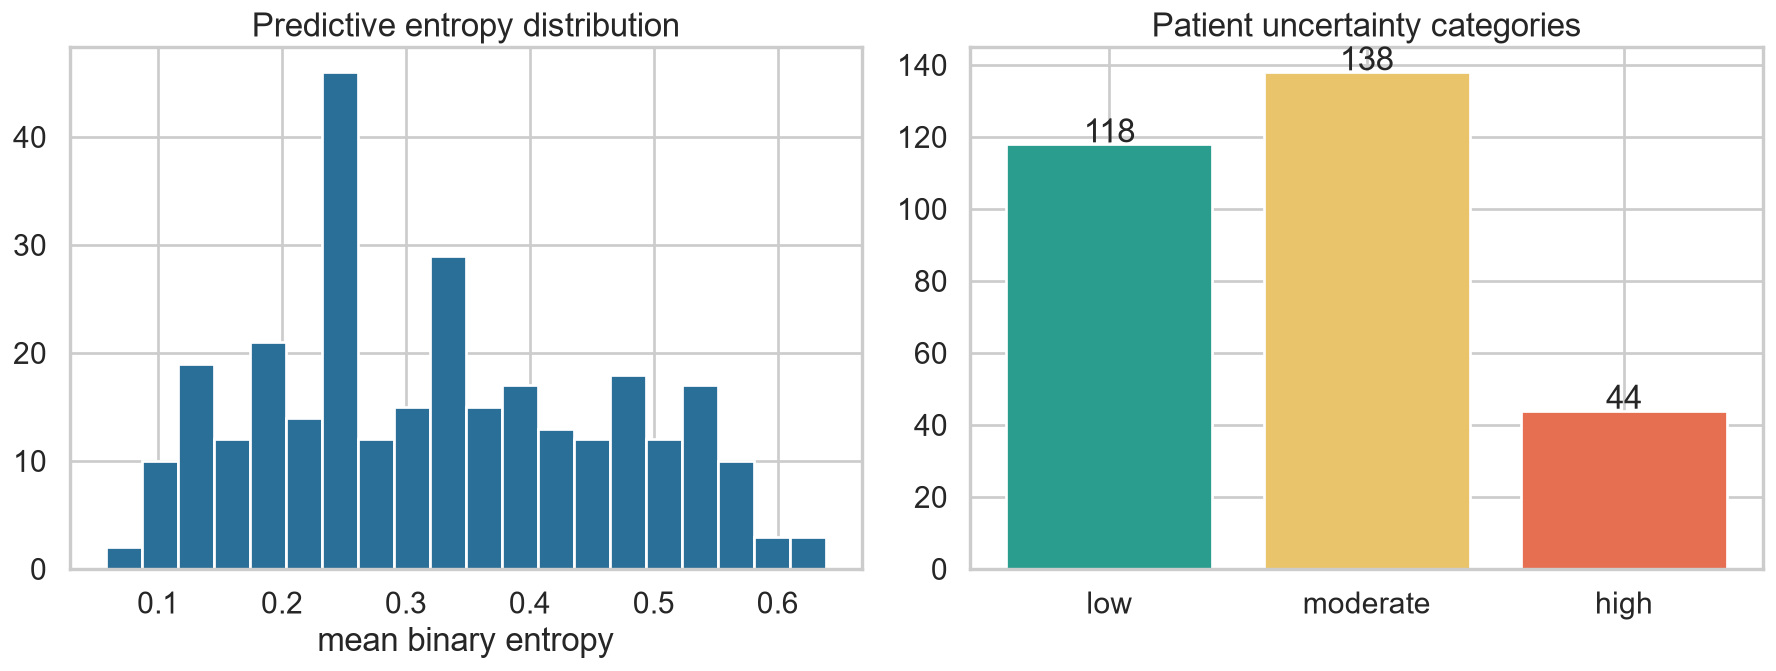

In [5]:
if (FIG / 'uncertainty_distribution.png').exists(): display(Image(str(FIG / 'uncertainty_distribution.png')))

## Explainability — global + per-label + local case studies

,feature,importance_mean
0,autres_maladies_pr_sent_es_par_le_patien__present,0.090512
1,Température axillaire (médiane IQR) (°C) /Axil...,0.018440
2,Diabète,0.012568
3,Douleur abdominale (stomac pain),0.012192
4,Pâleur cutanéo muqueuse ou Anémie (Mucosal ski...,0.010986
5,Vertige (Dizzy),0.009544
6,Douleur articulaire (Joint pain),0.007986
7,Convulsions généralisées ou focales (Generalis...,0.004760
8,Troubles de la conscience (Consciousness trouble),0.003940
9,"Haute température.(temperature, Hyperpyrexia)",0.002852


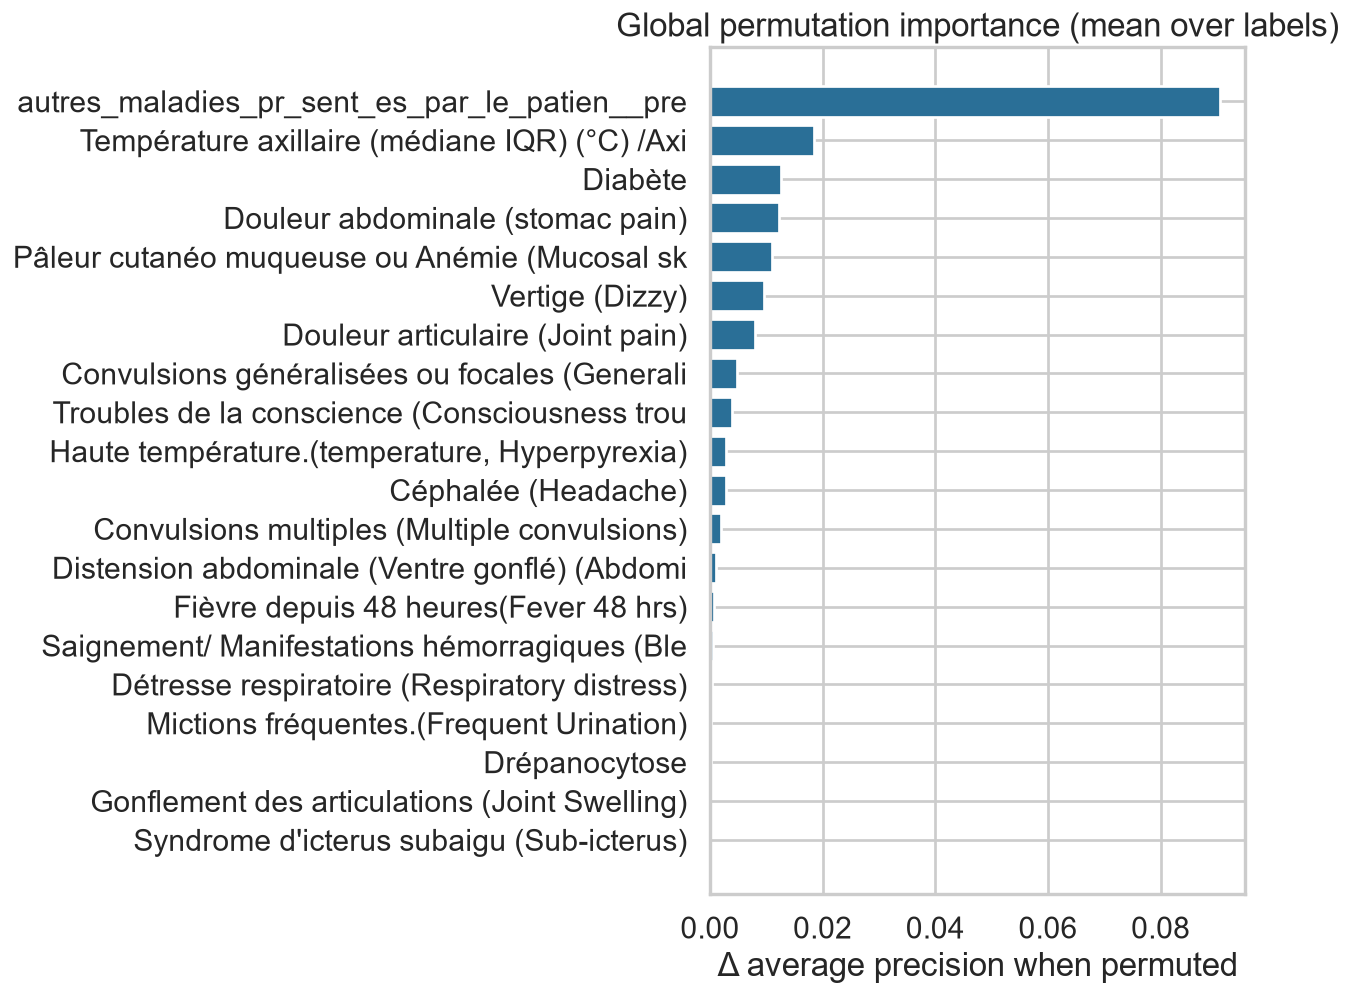

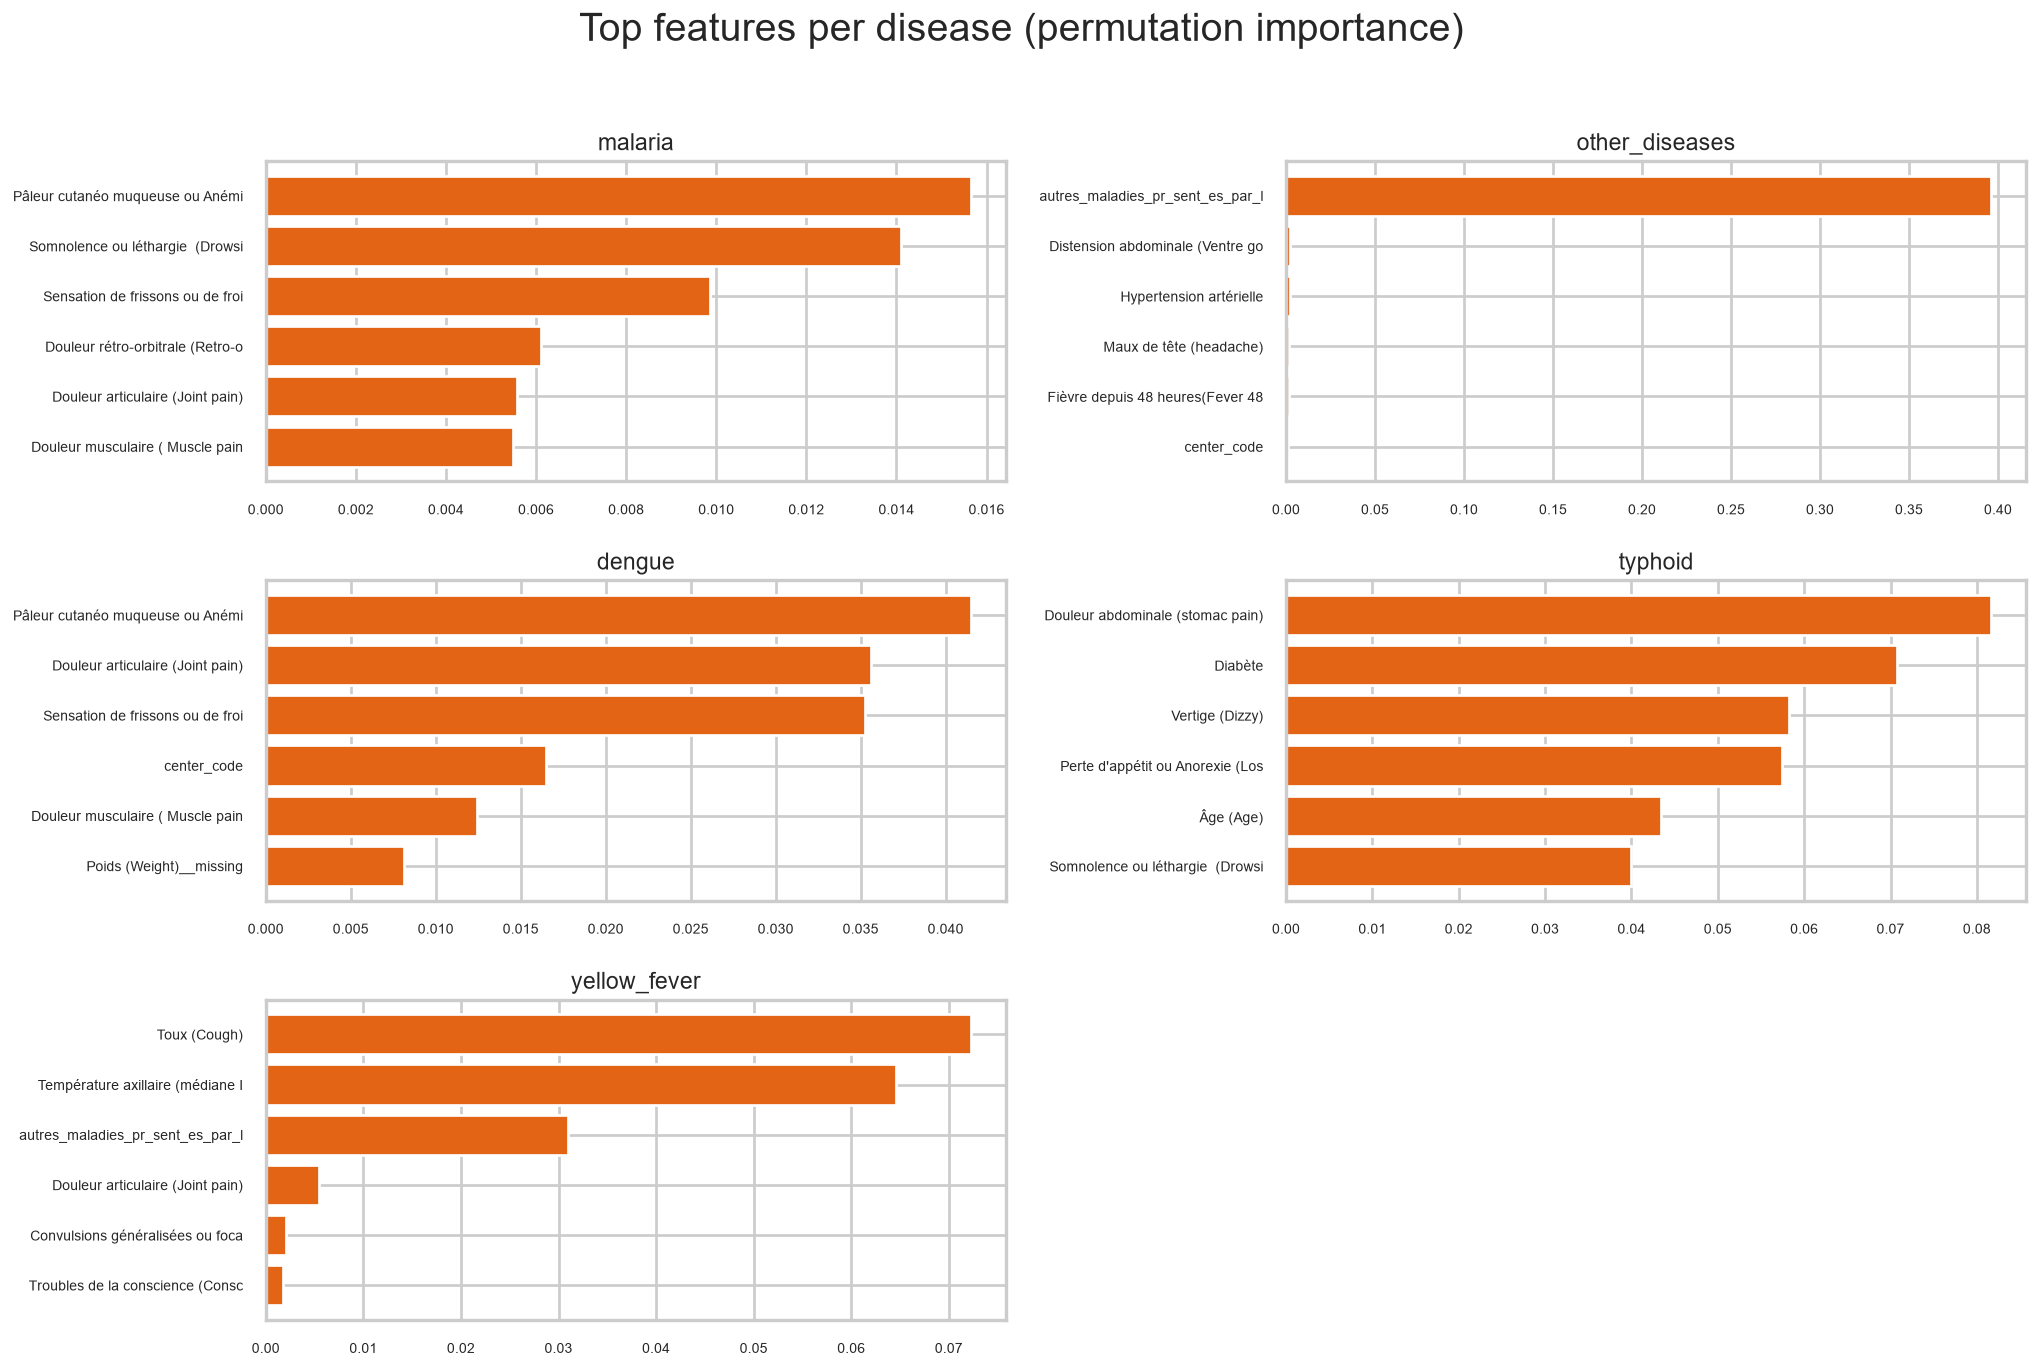

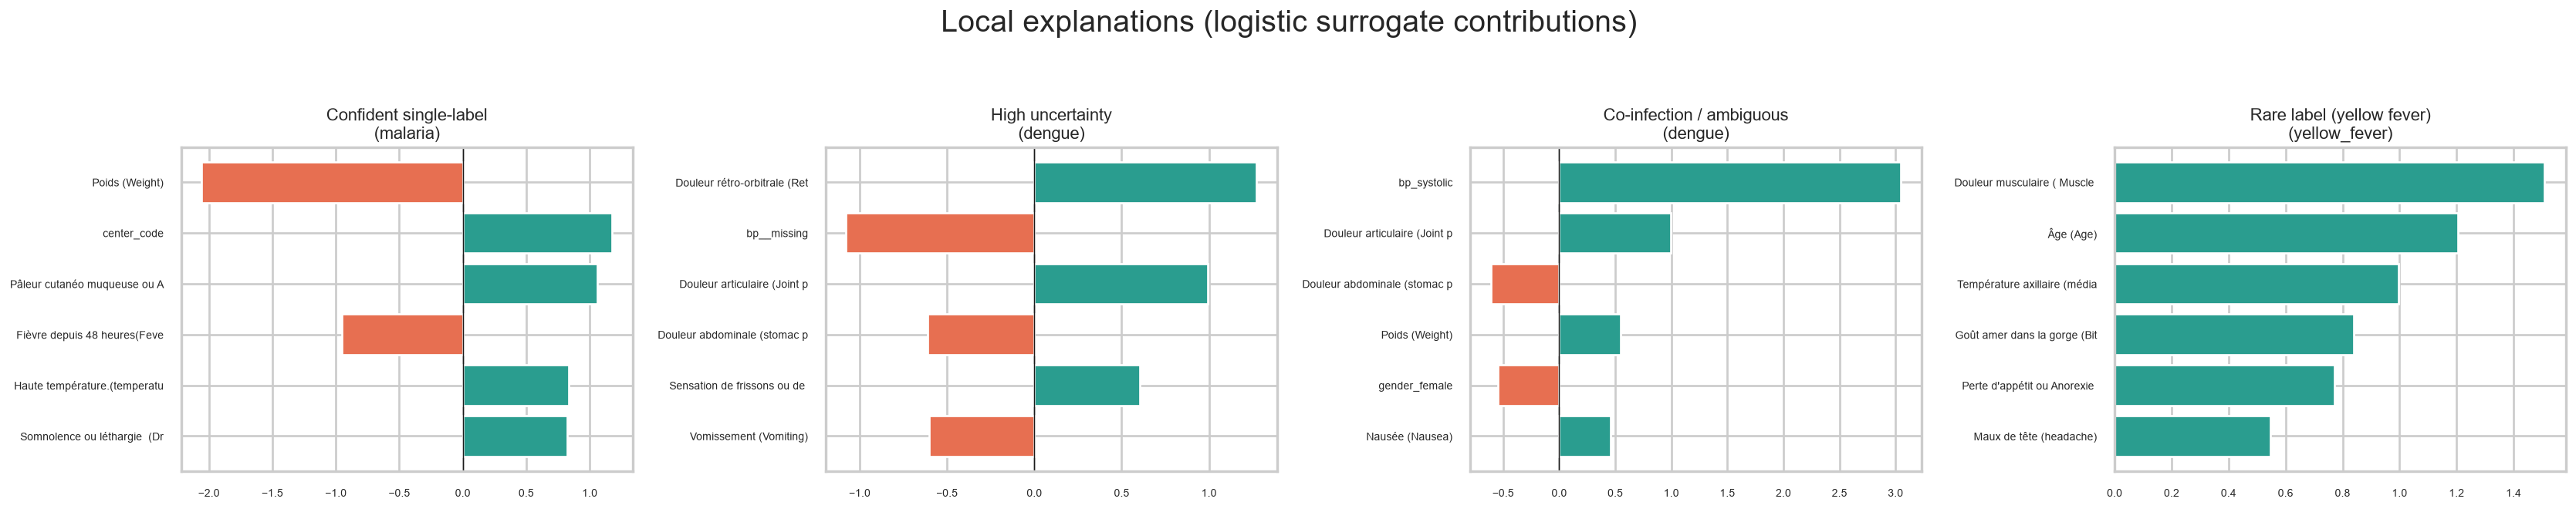

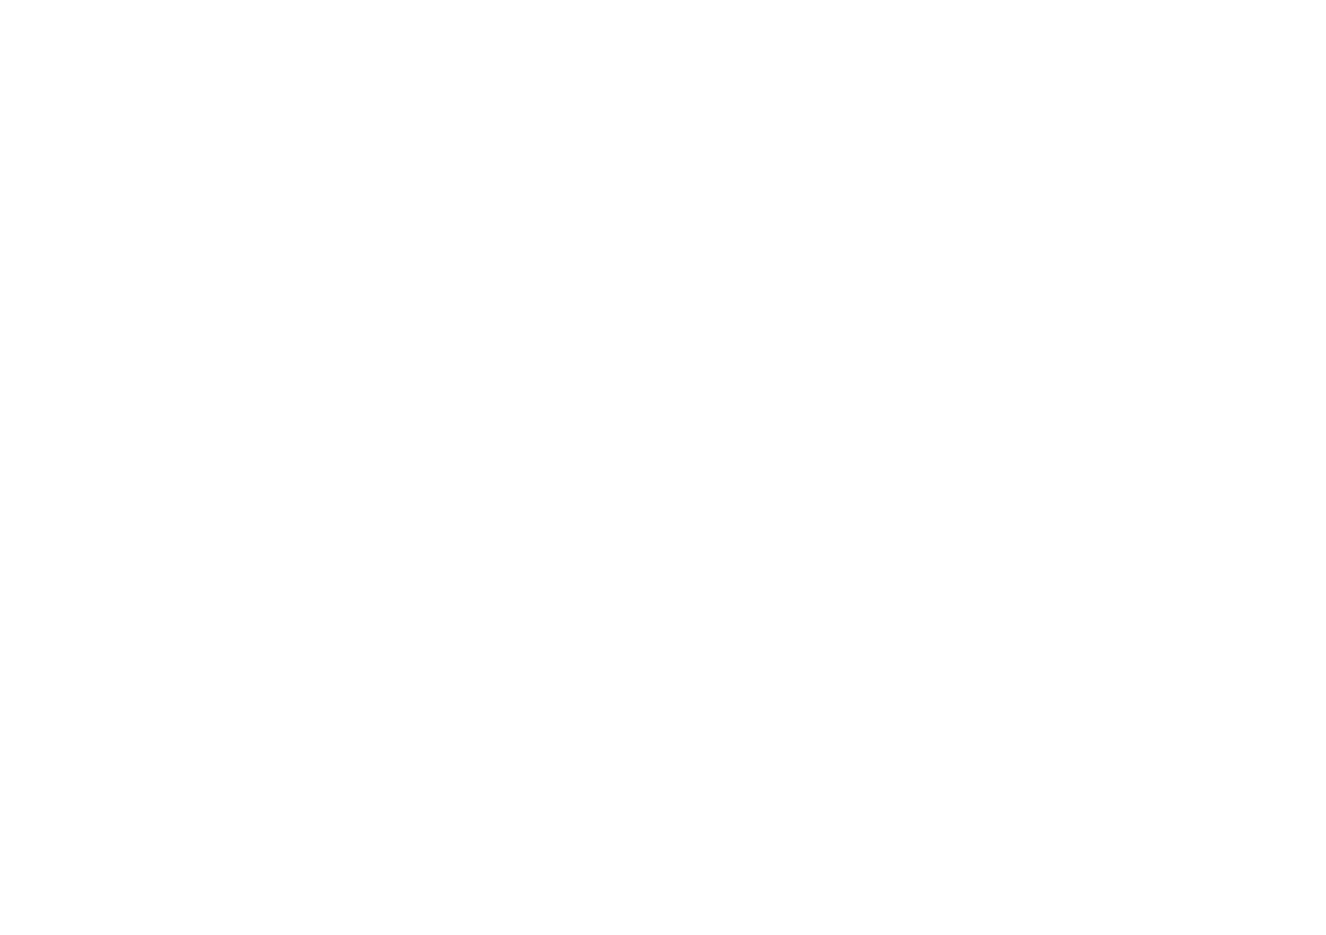

In [6]:
display(pd.read_csv(TAB / 'feature_importance_global.csv').head(12))
for f in ['feature_importance_global.png','feature_importance_per_label.png',
          'local_explanation_examples.png','shap_summary.png']:
    if (FIG / f).exists(): display(Image(str(FIG / f)))

## Triage engine + resource simulation

{'Confirmatory Test Priority': 88, 'Clinical Review': 87, 'Routine Monitoring': 66, 'Urgent Response Priority': 59}


,uuid,predicted_labels,conformal_set,uncertainty_level,triage_score,triage_category,recommended_action
0,df22d899-23a3-4c49-8059-6208c130f57d,"{malaria, dengue}","{malaria, dengue, typhoid, yellow_fever}",moderate,0.4461,Urgent Response Priority,Flag for urgent clinical evaluation / referral.
1,4a7ef2f3-4ff0-4215-8cb5-20ba8c8d4355,"{malaria, dengue, typhoid}","{malaria, dengue, typhoid, yellow_fever}",moderate,0.4635,Urgent Response Priority,Flag for urgent clinical evaluation / referral.
2,104f6bc8-f39a-482b-b680-7ac1f8cccc86,"{malaria, dengue}","{malaria, dengue, typhoid, yellow_fever}",moderate,0.4798,Urgent Response Priority,Flag for urgent clinical evaluation / referral.
3,26d7d04a-1a1c-4d4b-b64a-606f968e6d9c,{malaria},"{malaria, dengue, typhoid}",moderate,0.1835,Clinical Review,Manual clinician review and symptom monitoring.
4,eb694f52-51ff-488d-9beb-2923a572a4cf,"{malaria, dengue, yellow_fever}","{dengue, typhoid, yellow_fever}",moderate,0.3526,Confirmatory Test Priority,Prioritise confirmatory testing (rapid test / ...
5,92fee67e-e41c-41f7-85ad-121df731b37f,{malaria},"{malaria, dengue, yellow_fever}",moderate,0.2303,Clinical Review,Manual clinician review and symptom monitoring.
6,25435e6c-0ee8-403a-8916-711a3613e4e3,{malaria},"{malaria, dengue, typhoid}",moderate,0.2104,Clinical Review,Manual clinician review and symptom monitoring.
7,3d05f28c-9d33-4b7c-9417-0ff09d462209,"{malaria, other_diseases}","{malaria, other_diseases, typhoid}",moderate,0.3079,Confirmatory Test Priority,Prioritise confirmatory testing (rapid test / ...
8,95c3917b-1714-4210-8861-21f08d80b561,"{malaria, dengue, yellow_fever}","{dengue, typhoid, yellow_fever}",high,0.3885,Urgent Response Priority,Flag for urgent clinical evaluation / referral.
9,9acf30c2-8ac4-4009-b0de-032ed2eaddf7,"{malaria, other_diseases, dengue, yellow_fever}","{malaria, other_diseases, dengue, typhoid, yel...",moderate,0.3848,Confirmatory Test Priority,Prioritise confirmatory testing (rapid test / ...


,metric,count,pct
0,total_patients,300,100.00
1,predicted_malaria,300,100.00
2,predicted_other_diseases,94,31.33
3,predicted_dengue,102,34.00
4,predicted_typhoid,43,14.33
5,predicted_yellow_fever,44,14.67
6,tier_Routine_Monitoring,66,22.00
7,tier_Clinical_Review,87,29.00
8,tier_Confirmatory_Test_Priority,88,29.33
9,tier_Urgent_Response_Priority,59,19.67


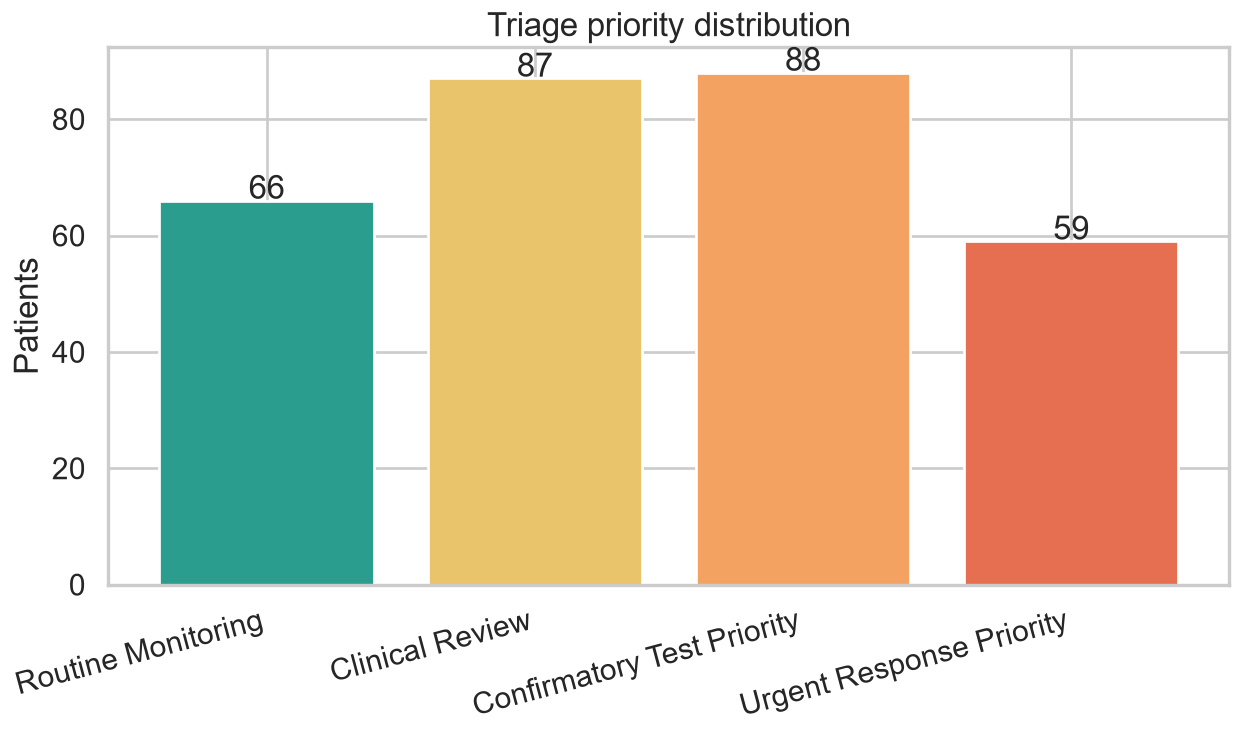

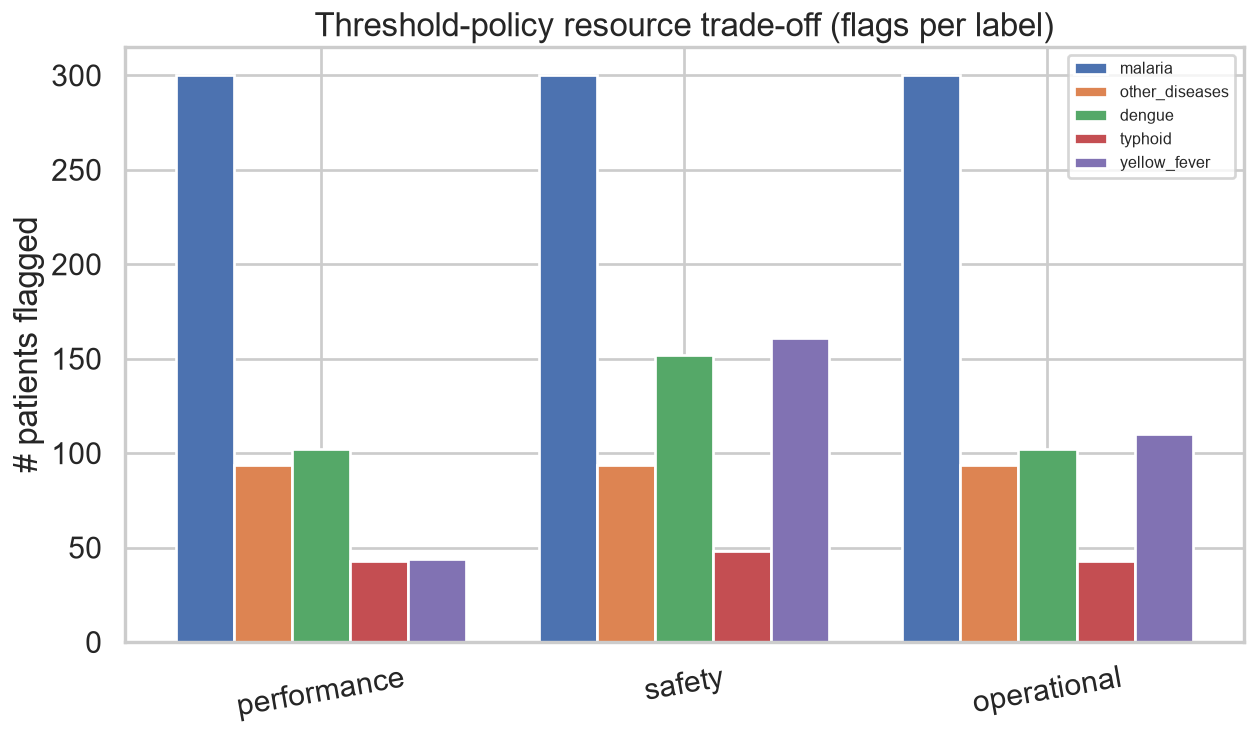

In [7]:
pt = pd.read_csv(TAB / 'vectra_patient_level_predictions.csv')
print(pt['triage_category'].value_counts().to_dict())
display(pt[['uuid','predicted_labels','conformal_set','uncertainty_level',
            'triage_score','triage_category','recommended_action']].head(10))
display(pd.read_csv(TAB / 'resource_simulation.csv'))
for f in ['resource_priority_distribution.png','threshold_policy_resource_tradeoff.png']:
    if (FIG / f).exists(): display(Image(str(FIG / f)))

**Takeaway:** VECTRA-X converts calibrated multi-label probabilities into a transparent, uncertainty-aware triage with decision-support actions — abstaining (multi-label conformal sets) when evidence is ambiguous.